# 04 Statistical Analysis

This notebook extends the project beyond descriptive EDA into statistical testing, downside-risk measurement, segmentation, and cautious trend interpretation. It starts from the cleaned NIFTY-50 dataset and uses the existing KPI tables when they are available, but all new outputs are written as separate statistical artifacts so the earlier EDA deliverables remain untouched.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'scripts').exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT / 'scripts') not in sys.path:
    sys.path.append(str(REPO_ROOT / 'scripts'))

from statistical_analysis import load_cleaned_data, load_optional_table, run_statistical_pipeline


## Load Processed Data and Supporting KPI Tables

The statistical notebook depends on `data/processed/nifty50_cleaned.csv`. It also tries to load the existing `stock_kpis.csv` and `sector_kpis.csv` tables so this notebook can connect the new statistical outputs back to the earlier KPI framework without rewriting those files.

In [2]:
df = load_cleaned_data()
stock_kpis = load_optional_table(REPO_ROOT / 'outputs' / 'tables' / 'stock_kpis.csv')
sector_kpis = load_optional_table(REPO_ROOT / 'outputs' / 'tables' / 'sector_kpis.csv')

coverage = pd.Series({
    'rows': int(df.shape[0]),
    'columns': int(df.shape[1] - 1),
    'date_start': df['date'].min().date().isoformat(),
    'date_end': df['date'].max().date().isoformat(),
    'stock_count': int(df['source_symbol'].nunique()),
    'industry_count': int(df['industry'].nunique(dropna=True)),
    'existing_stock_kpis_loaded': stock_kpis is not None,
    'existing_sector_kpis_loaded': sector_kpis is not None,
})
display(coverage.to_frame('value'))

if stock_kpis is not None:
    display(stock_kpis.head(5))
if sector_kpis is not None:
    display(sector_kpis.head(5))


,value
rows,235192
columns,35
date_start,2000-01-03
date_end,2021-04-30
stock_count,49
industry_count,13
existing_stock_kpis_loaded,True
existing_sector_kpis_loaded,True


,symbol,company_name,industry,start_date,end_date,trading_days,cumulative_return_percent,annualized_return_percent,volatility_percent,average_daily_return,max_drawdown_percent,risk_adjusted_return,average_volume,average_turnover_cr,average_delivery_percent,positive_return_day_ratio,close_above_vwap_ratio,liquidity_score,investor_confidence_score,opportunity_score
0,TCS,Tata Consultancy Services Ltd.,IT,2004-08-25,2021-04-30,3939,1907.214925,21.153025,23.277388,0.086906,-51.893547,0.908737,1.676762e+06,295.210205,54.942885,48.876540,47.982604,66.326531,77.551020,91.734694
1,RELIANCE,Reliance Industries Ltd.,ENERGY,2000-01-03,2021-04-30,5086,2783.777693,18.123923,26.173234,0.079696,-45.347698,0.692460,5.583028e+06,607.671458,43.503944,49.453449,44.609876,89.795918,36.224490,84.795918
2,ASIANPAINT,Asian Paints Ltd.,CONSUMER GOODS,2000-01-03,2021-04-30,5018,1400.998659,14.571577,20.323704,0.062180,-42.088180,0.716974,5.096721e+05,69.429186,62.557238,47.644176,47.870335,18.367347,85.000000,80.612245
3,HDFC,Housing Development Finance Corporation Ltd.,FINANCIAL SERVICES,2000-01-03,2021-04-30,5035,891.661540,12.167656,26.725903,0.059731,-52.946452,0.455276,1.848187e+06,262.075870,65.308810,47.474557,52.223897,63.265306,90.816327,79.693878
4,BAJAJ-AUTO,Bajaj Auto Ltd.,AUTOMOBILE,2008-05-26,2021-04-30,3046,517.065358,16.247934,22.868703,0.070119,-26.753660,0.710488,4.114639e+05,96.440240,50.940144,47.845097,47.033104,24.489796,60.918367,79.642857


,industry,constituent_stock_count,trading_days,cumulative_return_percent,annualized_return_percent,volatility_percent,average_daily_return,max_drawdown_percent,risk_adjusted_return,average_volume,average_turnover_cr,average_delivery_percent,positive_return_day_ratio,close_above_vwap_ratio,average_annual_return_percent,liquidity_score,investor_confidence_score,opportunity_score
0,CEMENT & CEMENT PRODUCTS,3,5200,2316.423192,16.689208,22.579364,0.071371,-63.346674,0.739135,6.978389e+05,125.615161,59.647748,50.339239,46.551074,20.900490,19.230769,90.000000,82.692308
1,PHARMA,3,5271,416.793220,8.168995,18.637088,0.038057,-40.740198,0.438319,4.218304e+06,315.088663,52.977908,50.659631,44.383717,9.724963,46.153846,69.615385,78.269231
2,IT,5,5225,791.304188,11.126960,23.451866,0.052790,-65.623327,0.474459,8.902191e+06,908.906410,48.095986,51.206182,46.532228,14.853905,73.076923,58.076923,77.307692
3,AUTOMOBILE,6,5295,445.582410,8.409841,20.622977,0.040489,-60.857547,0.407790,1.383072e+07,802.041607,47.467026,51.997738,45.250660,13.058829,76.923077,53.076923,75.769231
4,FINANCIAL SERVICES,9,5291,304.186759,6.878493,19.783362,0.034175,-64.362968,0.347691,3.090072e+07,2075.905466,51.152683,52.299284,46.607614,10.995975,100.000000,75.769231,70.769231


## Build the Statistical Artifacts

The reusable pipeline below generates all new tables and charts required for the statistical-analysis layer. Because these files are separate from the EDA outputs, Aryan's earlier charts and KPI outputs stay intact.

In [3]:
results = run_statistical_pipeline()
for name, path in results['table_paths'].items():
    print(f'{name}: {path}')
for name, path in results['chart_paths'].items():
    print(f'{name}: {path}')


statistical_test_results: /Users/aryanverma/Documents/DVA/DVA_capstone_2/outputs/tables/statistical_test_results.csv
risk_summary: /Users/aryanverma/Documents/DVA/DVA_capstone_2/outputs/tables/risk_summary.csv
stock_segments: /Users/aryanverma/Documents/DVA/DVA_capstone_2/outputs/tables/stock_segments.csv
recommendation_evidence: /Users/aryanverma/Documents/DVA/DVA_capstone_2/outputs/tables/recommendation_evidence.csv
correlation_heatmap: /Users/aryanverma/Documents/DVA/DVA_capstone_2/outputs/charts/correlation_heatmap.png
risk_return_segments: /Users/aryanverma/Documents/DVA/DVA_capstone_2/outputs/charts/risk_return_segments.png
max_drawdown_top10: /Users/aryanverma/Documents/DVA/DVA_capstone_2/outputs/charts/max_drawdown_top10.png
sector_statistical_comparison: /Users/aryanverma/Documents/DVA/DVA_capstone_2/outputs/charts/sector_statistical_comparison.png


## Correlation Analysis

The project brief asked for five specific relationship checks. These correlations are exploratory, not causal. Daily-return relationships use row-level trading observations, while return-vs-risk and liquidity-vs-risk-adjusted-return use stock-level summaries.

,analysis_name,scope,statistic,p_value,secondary_statistic,secondary_p_value,interpretation
0,daily_return_vs_volume,daily_observation,0.030316,2.078812e-46,0.034484,1.581680e-59,"The relationship is weak, positive, and statis..."
1,daily_return_vs_turnover,daily_observation,0.032143,5.952195e-52,0.043528,8.996358e-94,"The relationship is weak, positive, and statis..."
2,daily_return_vs_delivery_percent,daily_observation,-0.035809,3.359963e-60,-0.033433,1.048053e-52,"The relationship is weak, negative, and statis..."
3,volatility_vs_return,stock_level,-0.160068,2.719208e-01,-0.196224,1.766021e-01,"The relationship is weak, negative, and not st..."
4,liquidity_vs_risk_adjusted_return,stock_level,-0.149808,3.042338e-01,-0.161359,2.680195e-01,"The relationship is weak, negative, and not st..."


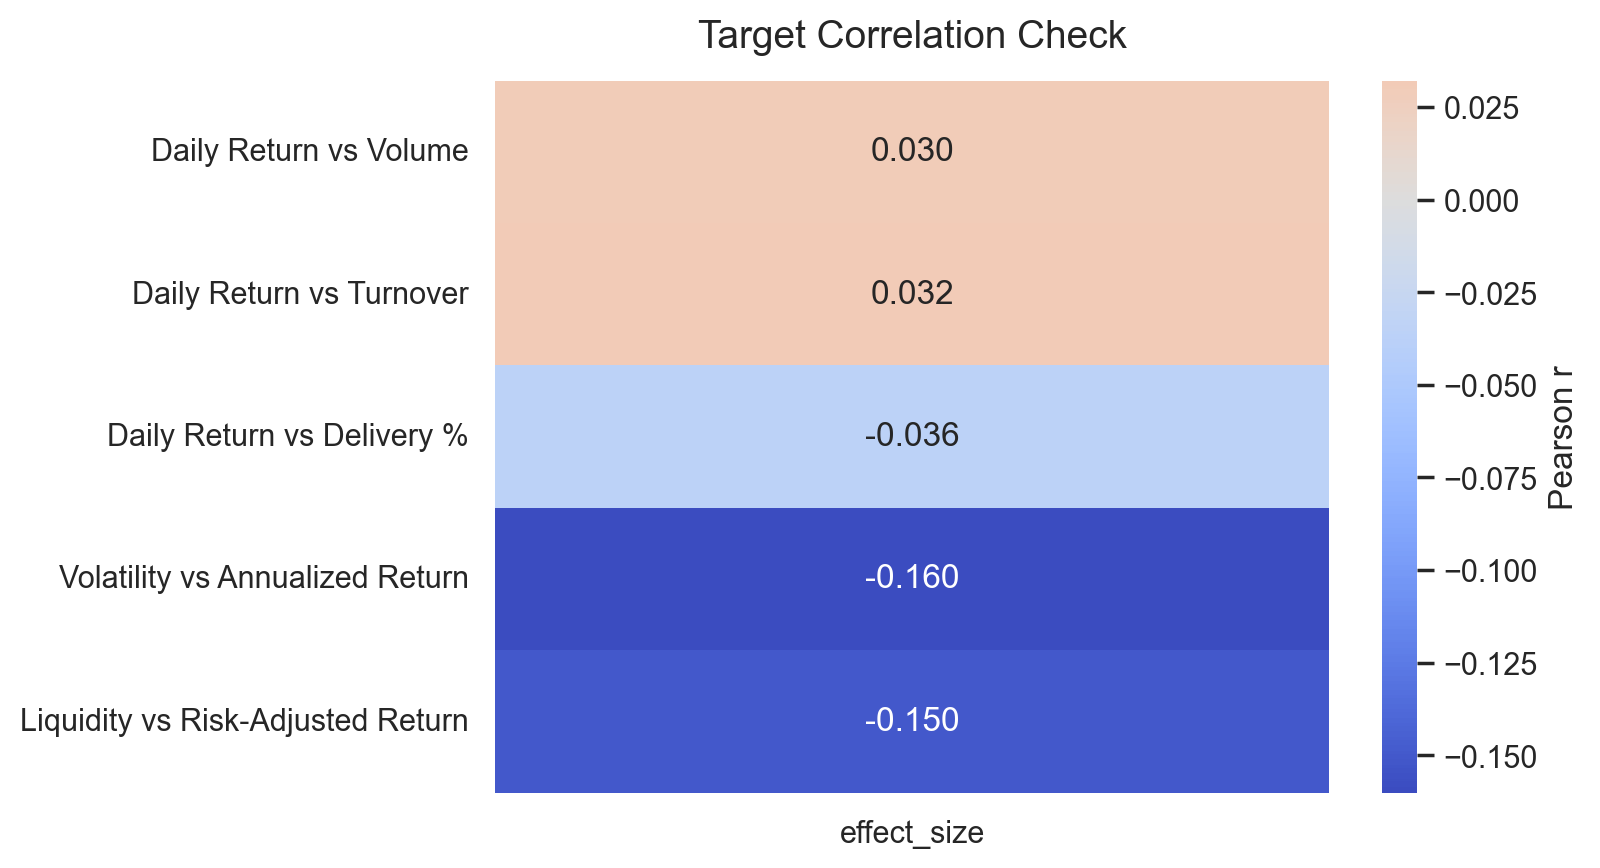

In [4]:
correlations = results['correlations']
display(correlations[['analysis_name', 'scope', 'statistic', 'p_value', 'secondary_statistic', 'secondary_p_value', 'interpretation']])
display(Image(filename=str(results['chart_paths']['correlation_heatmap'])))


## Hypothesis Testing

Two business-facing questions are tested here:

1. Do high-delivery stocks have different average returns than low-delivery stocks?
2. Do sector returns differ across industries?

The notebook checks assumptions and then chooses an appropriate test. In this dataset, the delivery split supports a two-sample t-test, while the sector comparison falls back to a non-parametric Kruskal-Wallis test because variance equality is not supported.

In [5]:
hypothesis_tests = results['hypothesis_tests']
display(hypothesis_tests[['analysis_name', 'test_name', 'statistic', 'p_value', 'null_hypothesis', 'alternative_hypothesis', 'interpretation']])


,analysis_name,test_name,statistic,p_value,null_hypothesis,alternative_hypothesis,interpretation
0,high_delivery_vs_low_delivery_returns,Independent two-sample t-test,-0.702882,0.485597,High-delivery and low-delivery stocks have the...,High-delivery and low-delivery stocks have dif...,Independent two-sample t-test does not reject ...
1,sector_return_difference_test,Kruskal-Wallis test,21.963435,0.037932,Sector return distributions are the same acros...,At least one sector has a different return dis...,Kruskal-Wallis test rejects the null hypothesi...


## Risk Analysis

Risk is measured in multiple ways because one metric alone can hide the shape of downside exposure. The summary below includes annualized volatility, max drawdown, downside volatility, and a historical 95% Value-at-Risk style estimate, then converts them into a three-level risk bucket.

,symbol,company_name,industry,annualized_return_percent,volatility_percent,max_drawdown_percent,downside_volatility_percent,historical_var_95_percent,historical_cvar_95_percent,risk_adjusted_return,liquidity_score,risk_score,risk_bucket
0,VEDL,Vedanta Ltd.,METALS,1.031552,40.167775,-92.420886,24.221127,4.174634,5.211508,0.025681,68.367347,98.979592,High
1,ZEEL,Zee Entertainment Enterprises Ltd.,MEDIA & ENTERTAINMENT,-3.704229,37.346384,-86.130071,23.106107,3.833524,4.941627,-0.099186,67.346939,94.387755,High
2,HINDALCO,Hindalco Industries Ltd.,METALS,6.620496,34.713140,-88.025251,21.396651,3.601808,4.559482,0.190720,66.326531,91.836735,High
3,TATAMOTORS,Tata Motors Ltd.,AUTOMOBILE,3.618580,35.677366,-85.203955,21.570917,3.688061,4.639038,0.101425,94.897959,91.326531,High
4,TATASTEEL,Tata Steel Ltd.,METALS,10.878518,34.274734,-84.876448,21.036034,3.620259,4.462635,0.317392,86.734694,87.244898,High
5,JSWSTEEL,JSW Steel Ltd.,METALS,8.912829,34.778622,-75.612951,21.254611,3.690397,4.548991,0.256273,57.142857,86.734694,High
6,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES,-4.577160,33.177973,-86.902923,20.668530,3.458803,4.433382,-0.137958,55.102041,86.734694,High
7,INDUSINDBK,IndusInd Bank Ltd.,FINANCIAL SERVICES,8.013288,32.840788,-82.151136,20.046602,3.443224,4.232303,0.244004,64.285714,81.122449,High
8,TITAN,Titan Company Ltd.,CONSUMER GOODS,-0.633870,31.079248,-95.187930,19.034722,3.349329,4.064140,-0.020395,24.489796,81.122449,High
9,ICICIBANK,ICICI Bank Ltd.,FINANCIAL SERVICES,-2.098120,31.869645,-85.507936,19.438234,3.370221,4.202803,-0.065834,94.897959,80.102041,High


,stock_count
risk_bucket,
High,17
Low,16
Medium,16


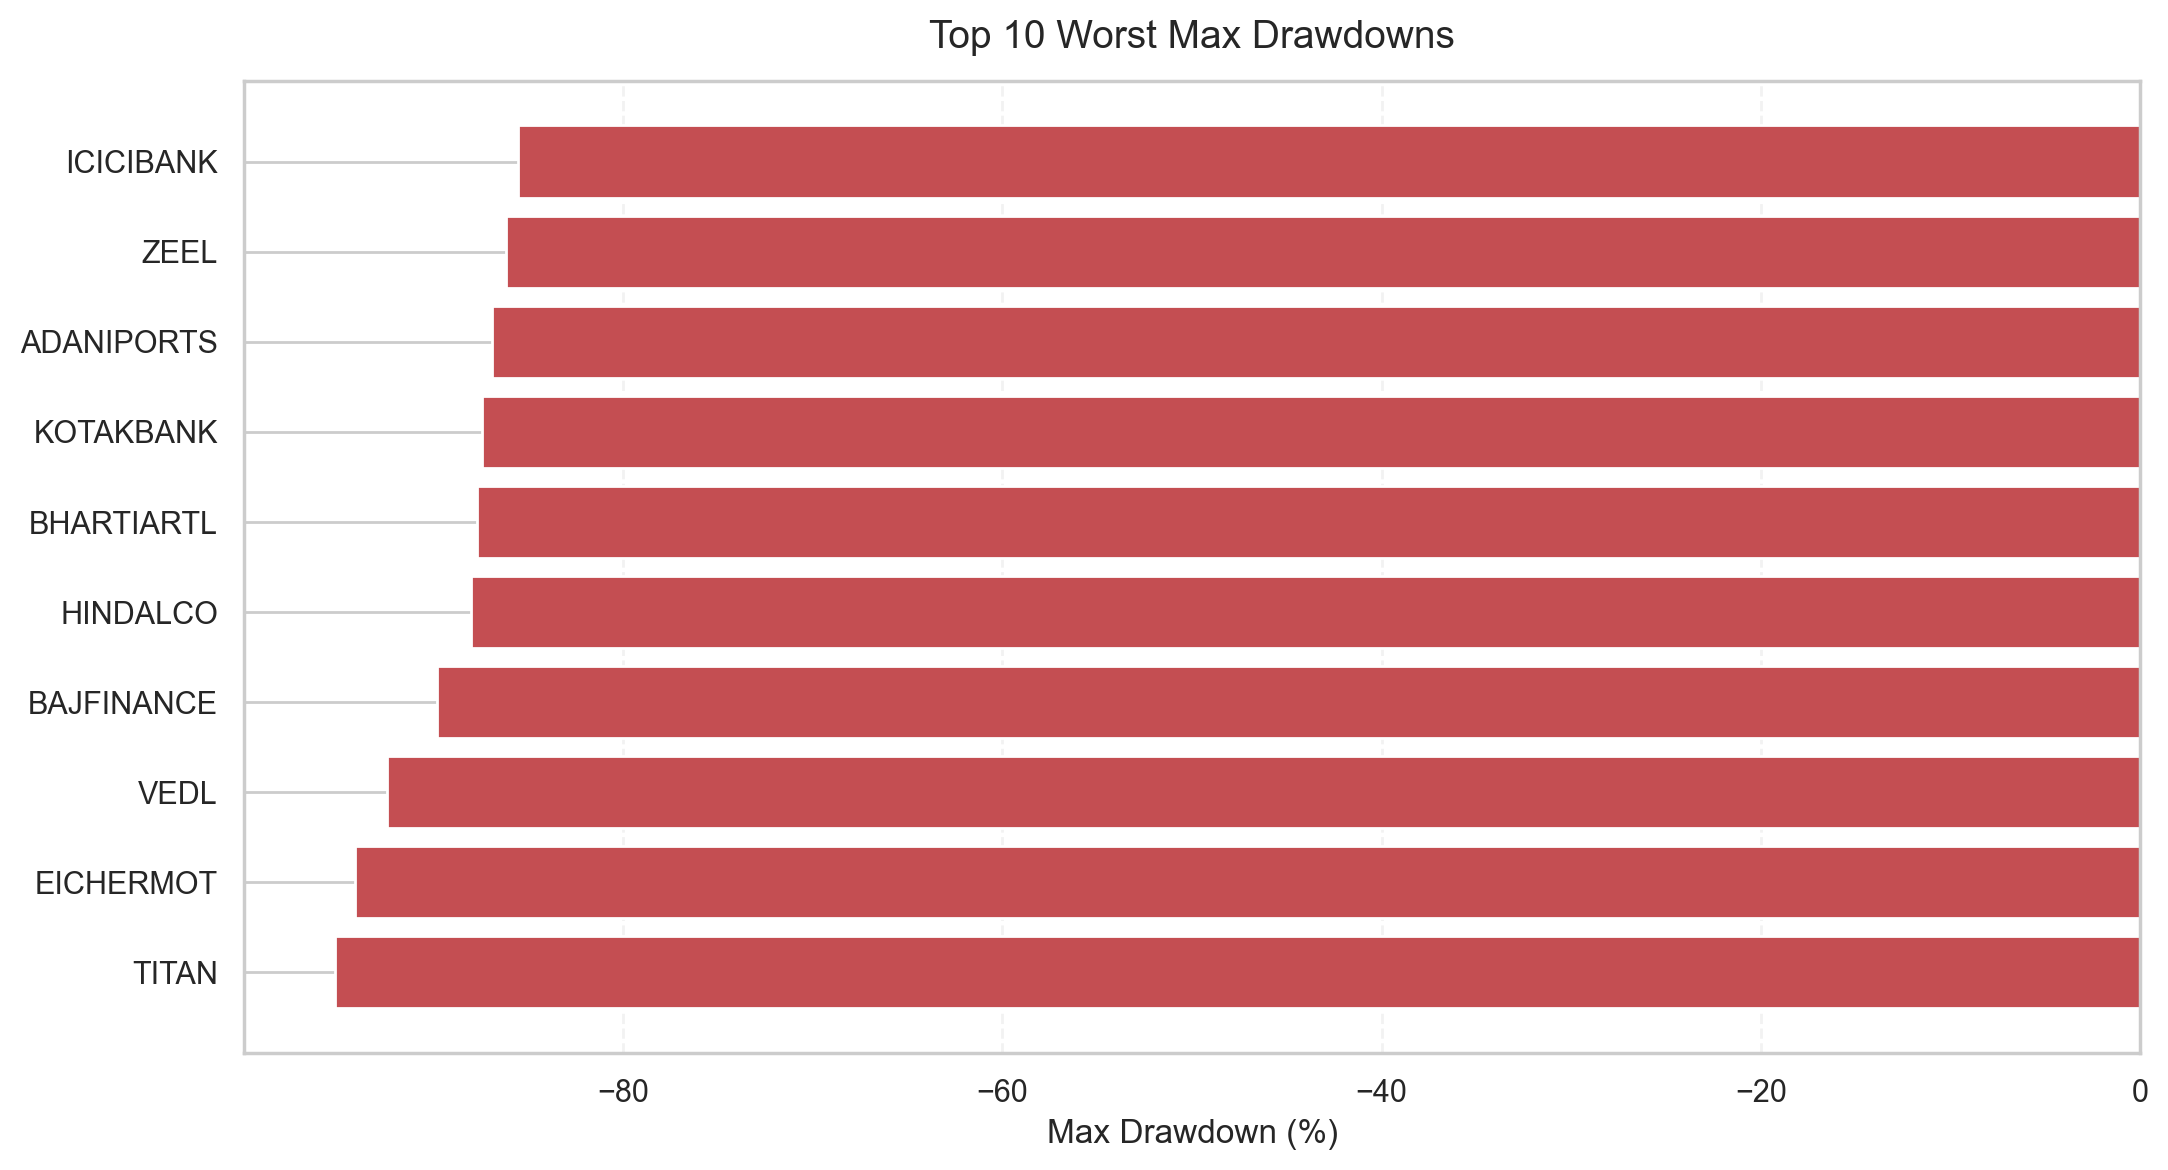

In [6]:
risk_summary = results['risk_summary']
display(risk_summary.head(10))
display(risk_summary['risk_bucket'].value_counts().rename_axis('risk_bucket').to_frame('stock_count'))
display(Image(filename=str(results['chart_paths']['max_drawdown_top10'])))


## Segmentation Method Choice

A five-cluster KMeans solution would only be appropriate if the stock universe showed a stable cluster structure after scaling the core return-risk-liquidity features. The brief explicitly allows a transparent rule-based method if KMeans is not well supported, so the notebook checks that first.

In [7]:
segment_features = results['stock_summary'][[
    'annualized_return_percent',
    'volatility_percent',
    'risk_adjusted_return',
    'liquidity_score',
    'average_delivery_percent',
    'max_drawdown_percent',
    'downside_volatility_percent',
    'historical_var_95_percent',
]].replace([float('inf'), float('-inf')], pd.NA).fillna(method='ffill').fillna(method='bfill')
scaled = StandardScaler().fit_transform(segment_features)
silhouette_rows = []
for k in range(3, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=25)
    labels = model.fit_predict(scaled)
    silhouette_rows.append({'k': k, 'silhouette_score': silhouette_score(scaled, labels)})
silhouette_df = pd.DataFrame(silhouette_rows)
display(silhouette_df)


/var/folders/k9/tltv9sc50z38hk56y_m3zptm0000gn/T/ipykernel_84504/1664155582.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  segment_features = results['stock_summary'][[


,k,silhouette_score
0,3,0.269643
1,4,0.255505
2,5,0.219403
3,6,0.234828


## Stock Segmentation

The five-cluster solution is not the strongest silhouette result, so the final segmentation uses an interpretable rule-based scoring approach instead of forcing unstable clusters. The resulting labels are:

- Stable Compounders
- High Growth High Risk
- Liquid Trading Candidates
- Weak Risk-Return Candidates
- Defensive / Low Volatility

This keeps the segmentation easy to explain in the report and easy to reproduce in Tableau.

,symbol,segment,segment_score,annualized_return_percent,volatility_percent,risk_adjusted_return,risk_bucket,segment_rationale
0,NESTLEIND,Defensive / Low Volatility,97.959184,7.154232,18.938587,0.377760,Low,Volatility (18.94%) and downside risk (11.40%)...
1,BRITANNIA,Defensive / Low Volatility,95.510204,0.893340,19.765273,0.045197,Low,Volatility (19.77%) and downside risk (12.21%)...
2,ASIANPAINT,Defensive / Low Volatility,93.061224,14.571577,20.323704,0.716974,Low,Volatility (20.32%) and downside risk (12.34%)...
3,POWERGRID,Defensive / Low Volatility,89.795918,-4.101506,21.182249,-0.193629,Low,Volatility (21.18%) and downside risk (13.02%)...
4,HDFCBANK,Defensive / Low Volatility,88.571429,10.512126,21.957507,0.478749,Low,Volatility (21.96%) and downside risk (13.25%)...
5,NTPC,Defensive / Low Volatility,83.877551,-2.598461,22.686528,-0.114538,Low,Volatility (22.69%) and downside risk (13.51%)...
6,HINDUNILVR,Defensive / Low Volatility,79.387755,-0.691092,23.356696,-0.029589,Low,Volatility (23.36%) and downside risk (14.42%)...
7,ULTRACEMCO,Defensive / Low Volatility,72.653061,10.572793,25.576137,0.413385,Medium,Volatility (25.58%) and downside risk (15.55%)...
8,CIPLA,Defensive / Low Volatility,70.816327,-1.298841,23.383023,-0.055546,Low,Volatility (23.38%) and downside risk (14.39%)...
9,SUNPHARMA,Defensive / Low Volatility,70.612245,10.325665,25.890560,0.398820,Low,Volatility (25.89%) and downside risk (15.51%)...


,stock_count
segment,
Weak Risk-Return Candidates,12
Defensive / Low Volatility,11
High Growth High Risk,9
Liquid Trading Candidates,9
Stable Compounders,8


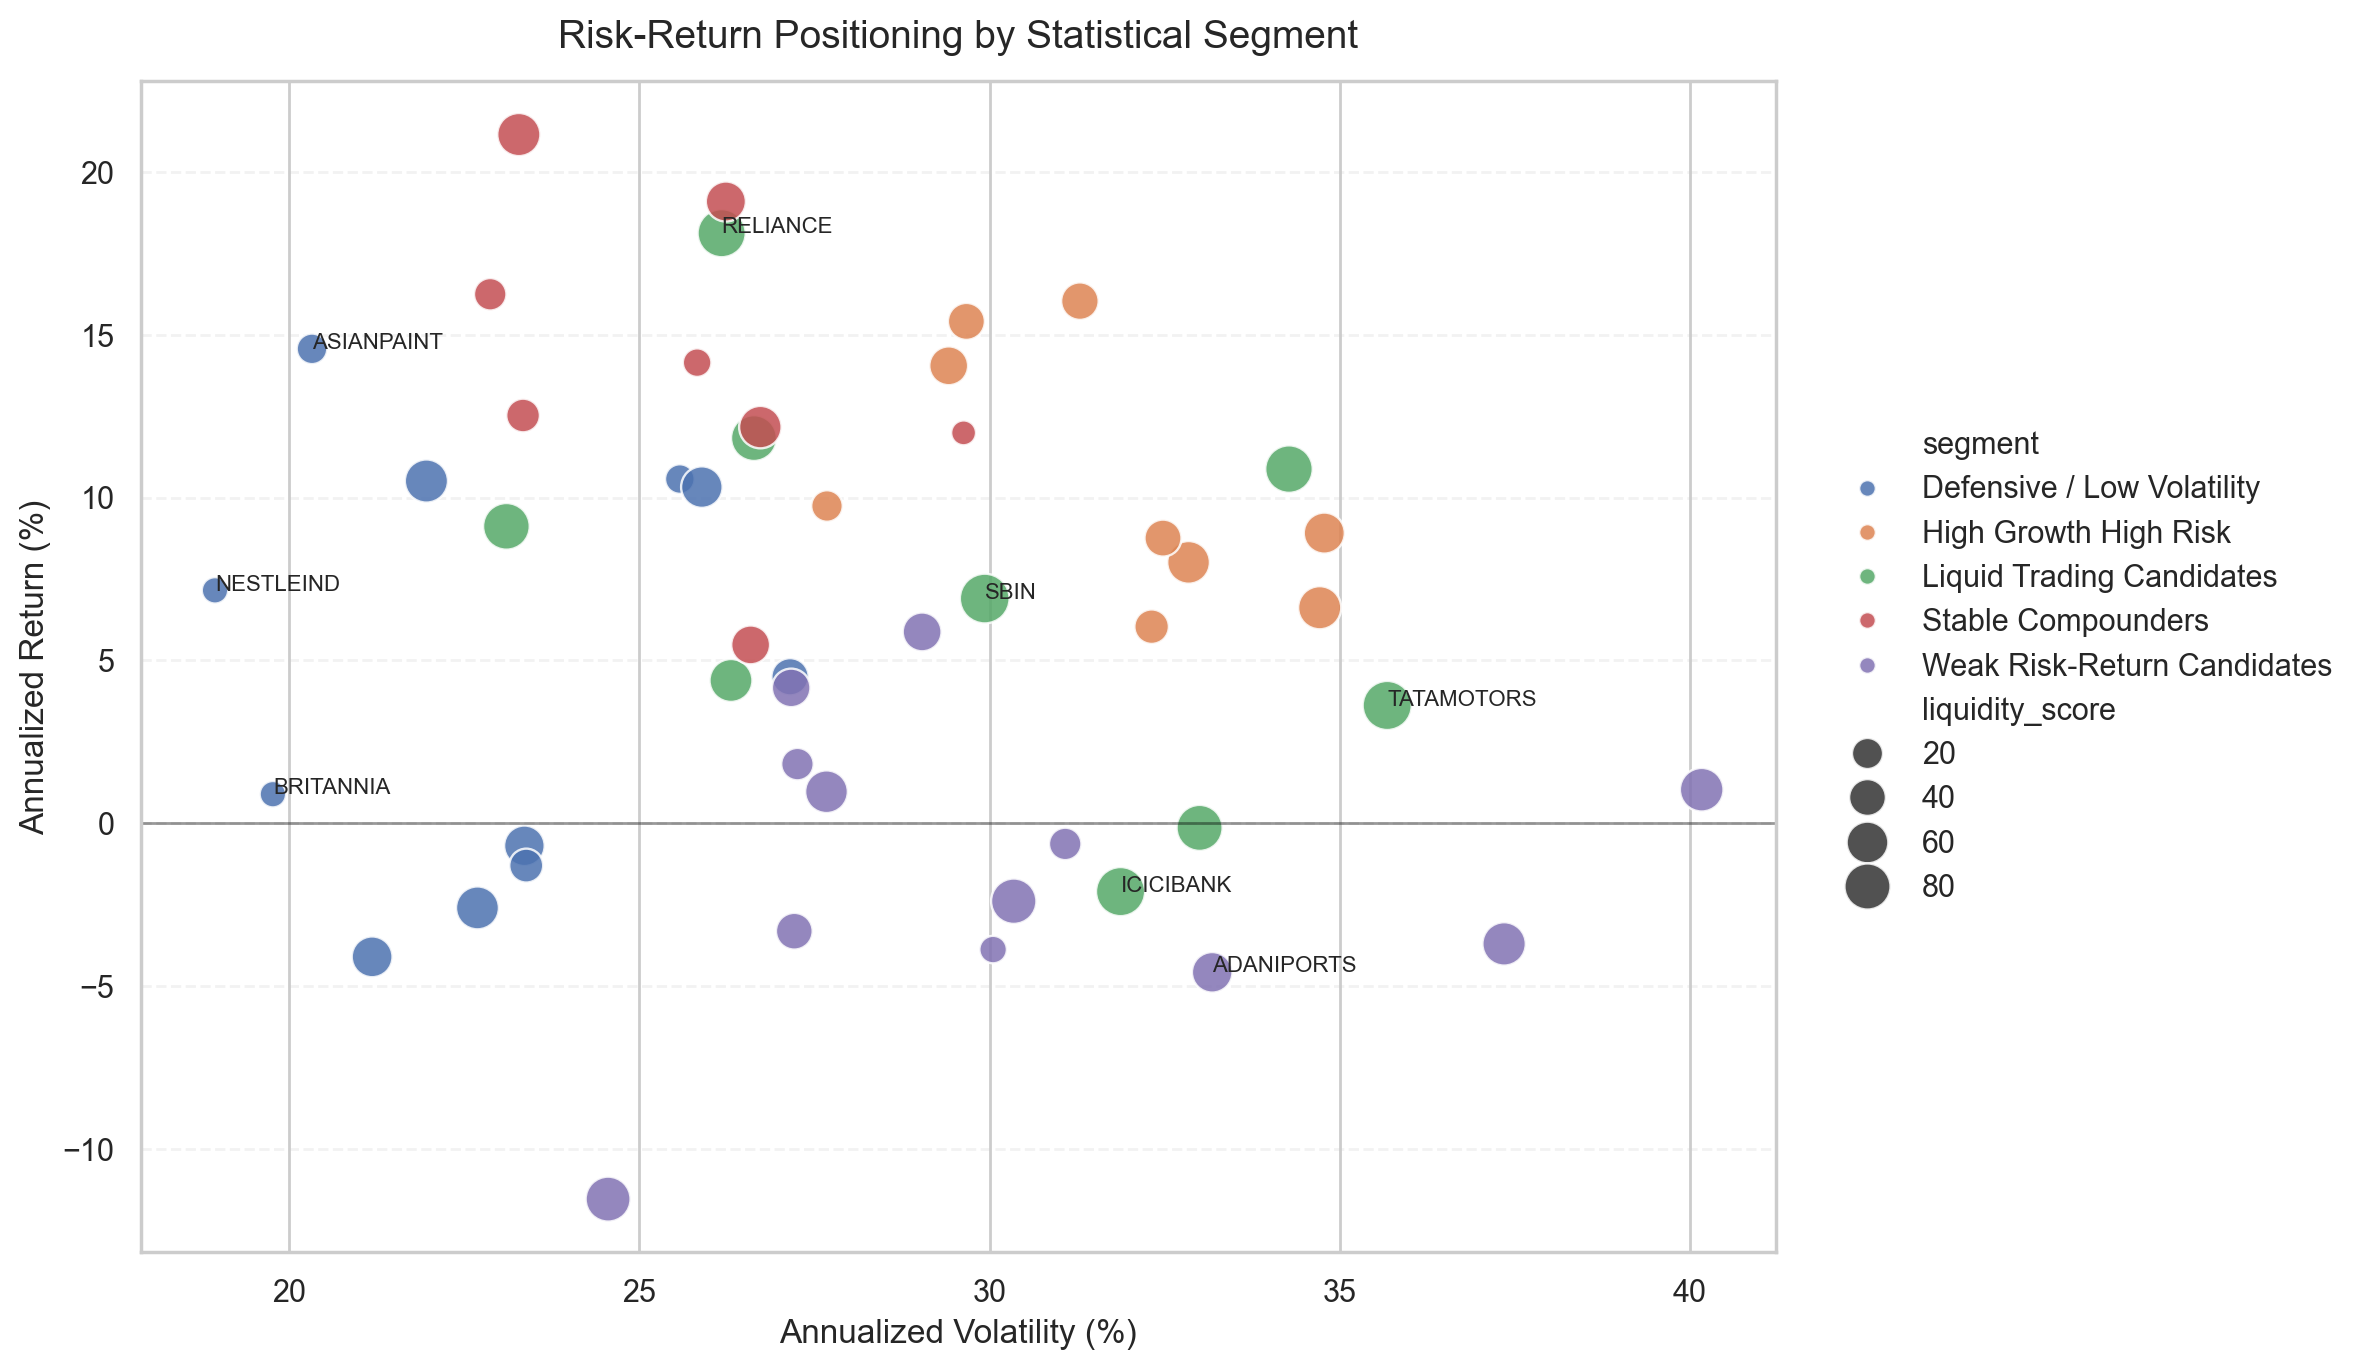

In [8]:
segments = results['segments']
display(segments[['symbol', 'segment', 'segment_score', 'annualized_return_percent', 'volatility_percent', 'risk_adjusted_return', 'risk_bucket', 'segment_rationale']].head(20))
display(segments['segment'].value_counts().rename_axis('segment').to_frame('stock_count'))
display(Image(filename=str(results['chart_paths']['risk_return_segments'])))


## Trend Analysis

The forecasting requirement is handled conservatively through moving-average trend analysis. This is not a claim of predictive accuracy. It is a regime-check tool that shows whether shorter-term momentum is above or below the medium-term trend for the market and sectors.

In [9]:
market_trend = results['trend_analysis']['market_trend']
sector_trend = results['trend_analysis']['sector_trend']
display(market_trend.tail(5)[['date', 'market_index', 'ma_20', 'ma_60', 'trend_signal']])
display(sector_trend[['industry', 'ma_gap_percent', 'trend_signal']].head(10))


,date,market_index,ma_20,ma_60,trend_signal
5301,2021-04-26,364.464096,364.803585,368.052732,Downtrend
5302,2021-04-27,368.493946,365.178371,368.101705,Downtrend
5303,2021-04-28,372.343585,366.072923,368.312089,Downtrend
5304,2021-04-29,372.298121,366.734817,368.557366,Sideways
5305,2021-04-30,369.932069,366.948062,368.844539,Downtrend


,industry,ma_gap_percent,trend_signal
0,METALS,7.072069,Uptrend
1,CEMENT & CEMENT PRODUCTS,5.768312,Uptrend
2,PHARMA,4.389061,Uptrend
3,IT,2.147292,Uptrend
4,SERVICES,1.759512,Uptrend
5,CONSUMER GOODS,1.465013,Uptrend
6,TELECOM,-2.939329,Downtrend
7,MEDIA & ENTERTAINMENT,-3.017859,Downtrend
8,ENERGY,-3.292027,Downtrend
9,FINANCIAL SERVICES,-4.309608,Downtrend


## Recommendation Evidence

The recommendation table converts the statistical outputs into decision-ready candidates for the final report. Each candidate includes the insight, the evidence behind it, the action, the likely impact, and a feasibility note.

,recommendation_id,theme,insight,statistical_evidence,recommended_action,expected_business_impact,feasibility_note
0,R1,Core Compounder Basket,A small set of names combines strong annualize...,"Top stable-compounder candidates TCS, BAJAJ-AU...",Use these stocks as the core shortlist for lon...,Improves the odds of holding names with both w...,High feasibility because the basket uses exist...
1,R2,Risk-Capped Growth Sleeve,"Growth-heavy names can add upside, but their l...","High-growth/high-risk names JSWSTEEL, HCLTECH,...",Treat the segment as a capped tactical sleeve ...,Keeps upside optionality while reducing the ch...,Operationally simple because the segment is al...
2,R3,Execution-Friendly Trading List,The most liquid names remain the easiest to tr...,"Stocks such as SBIN, ICICIBANK, TATAMOTORS sit...",Use the liquid segment as the default short-te...,Improves execution practicality and lowers sli...,Very feasible because liquidity scores already...
3,R4,Defensive Rotation Rule,"When broad momentum softens, lower-volatility ...",The market closes the sample with a downtrend ...,Use a simple moving-average regime filter to t...,Can reduce portfolio swings during weaker mome...,Moderate feasibility because it needs only rol...
4,R5,Deprioritize Weak Risk-Return Areas,Some names and sectors fail to compensate inve...,"Weak candidates such as ADANIPORTS, EICHERMOT,...",Underweight or explicitly flag weak risk-retur...,Reduces false positives from chasing liquidity...,High feasibility because the rule can be encod...


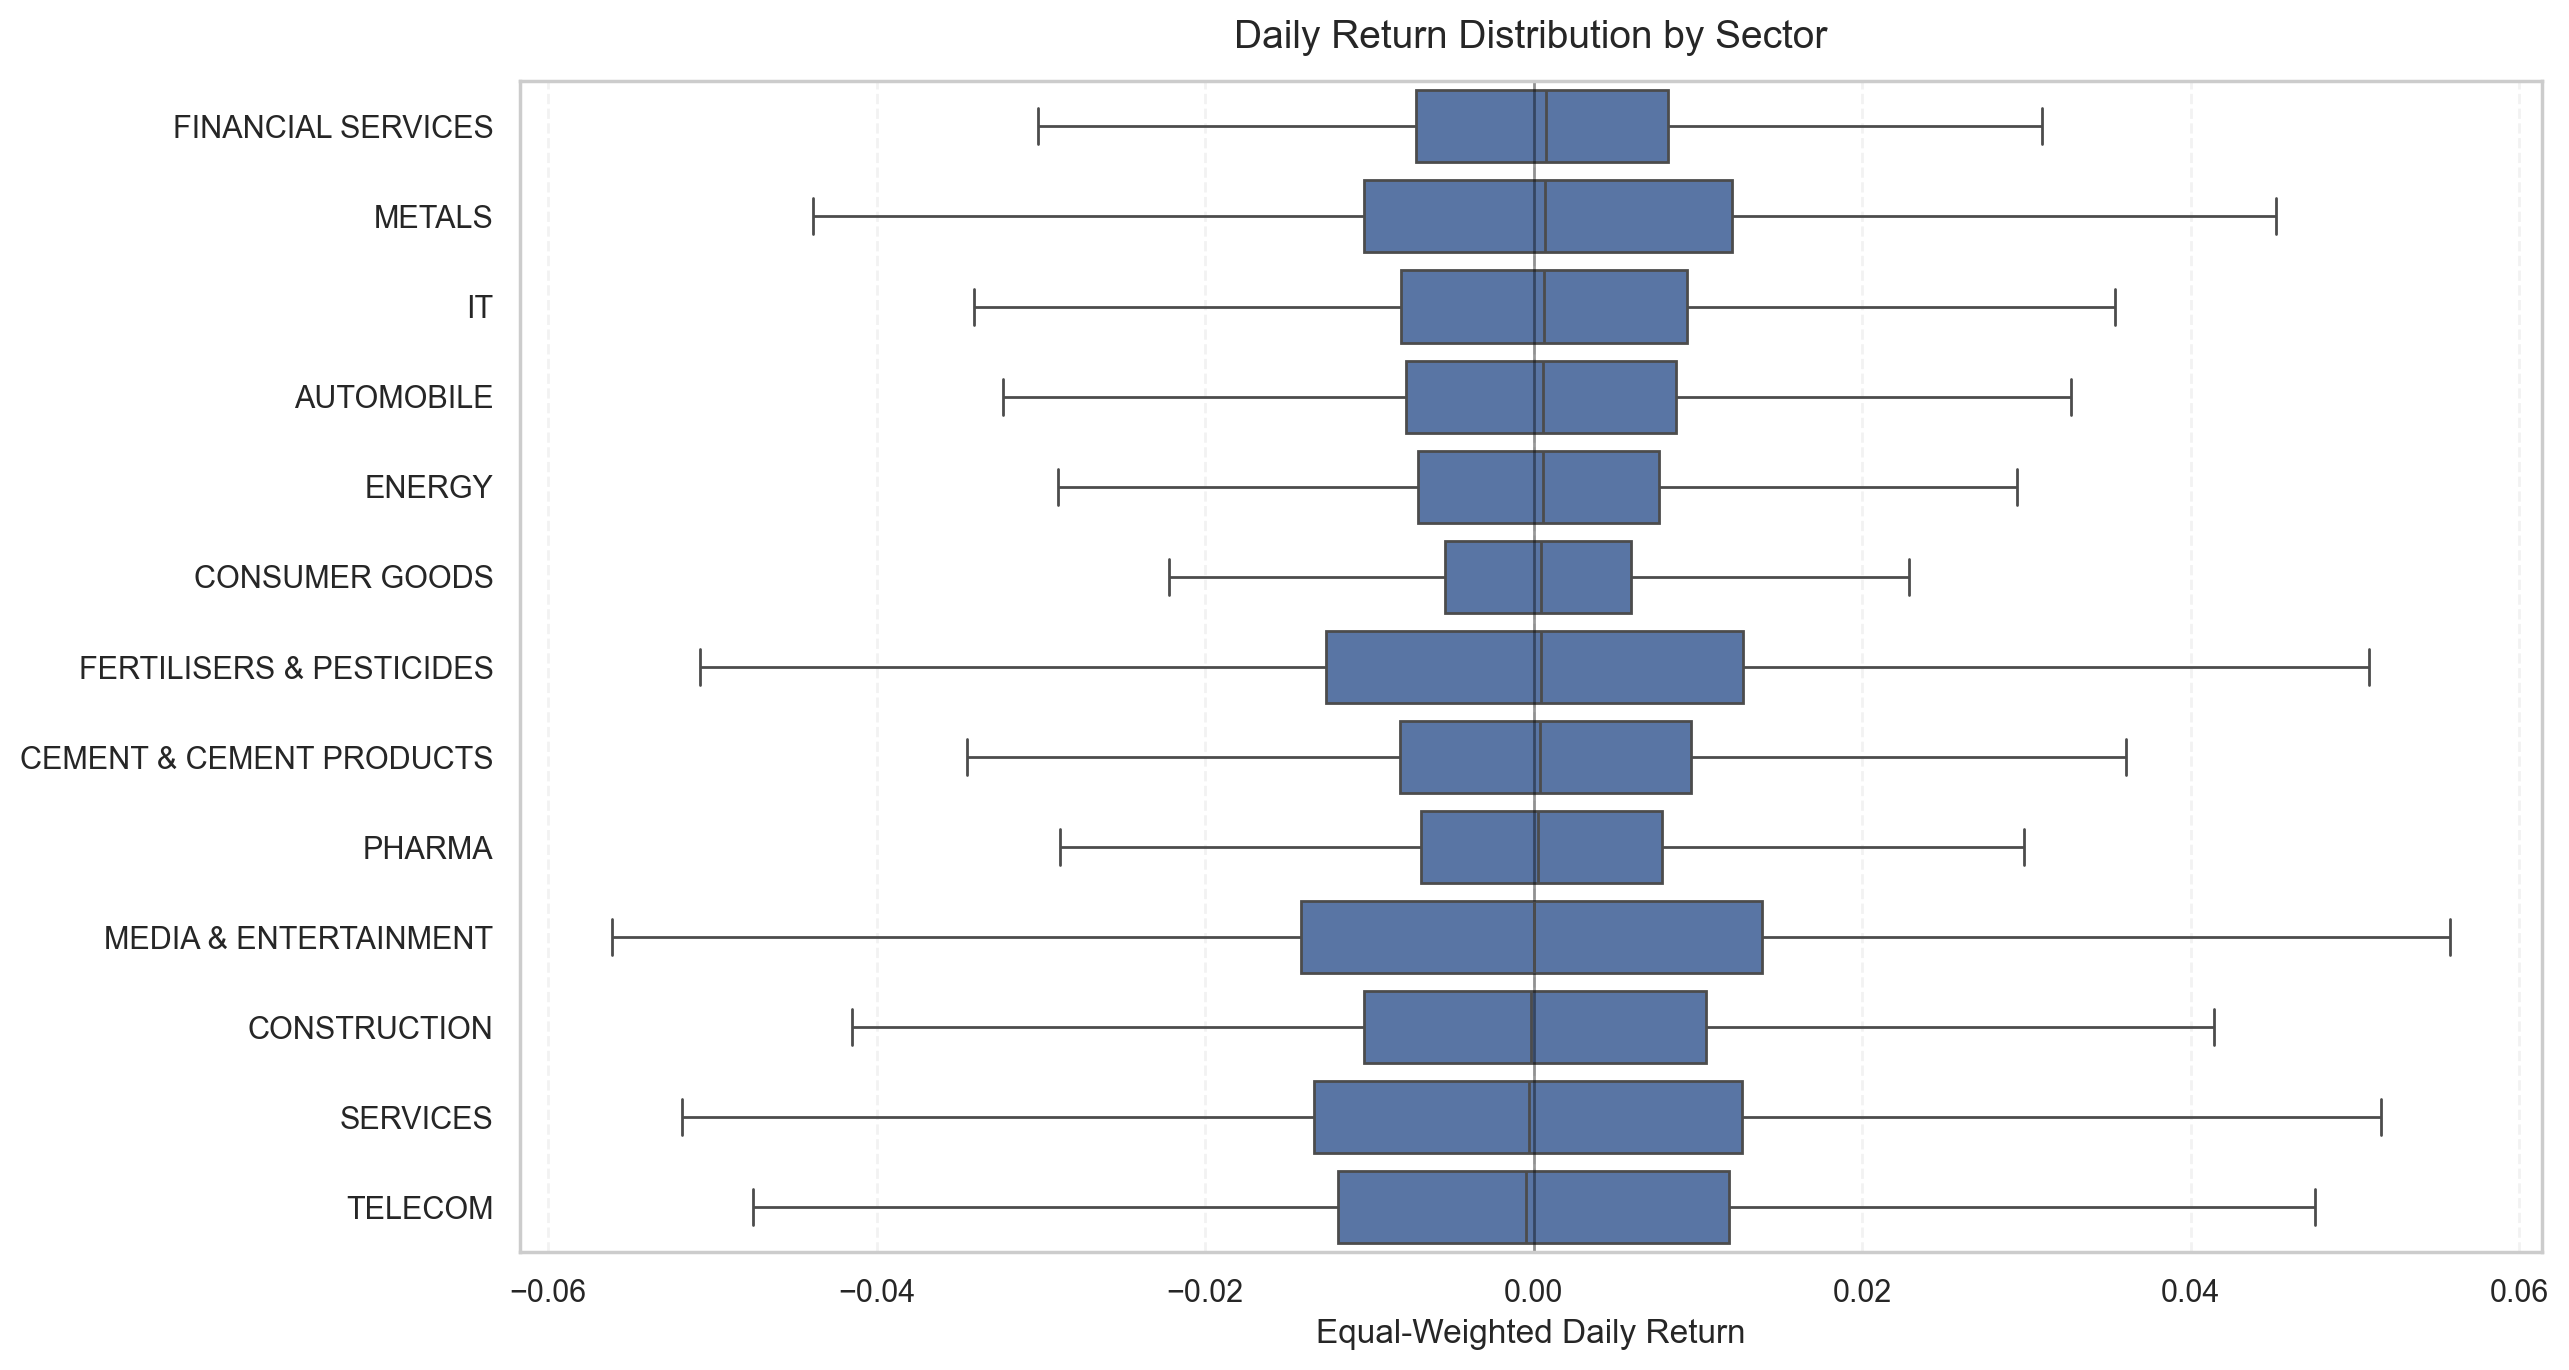

In [10]:
recommendation_evidence = results['recommendation_evidence']
display(recommendation_evidence)
display(Image(filename=str(results['chart_paths']['sector_statistical_comparison'])))


## Output Files

The notebook writes the following separate statistical outputs:

- `outputs/tables/statistical_test_results.csv`
- `outputs/tables/risk_summary.csv`
- `outputs/tables/stock_segments.csv`
- `outputs/tables/recommendation_evidence.csv`
- `outputs/charts/correlation_heatmap.png`
- `outputs/charts/risk_return_segments.png`
- `outputs/charts/max_drawdown_top10.png`
- `outputs/charts/sector_statistical_comparison.png`

In [11]:
pd.Series({name: str(path) for name, path in results['table_paths'].items()}, name='table_path')

statistical_test_results    /Users/aryanverma/Documents/DVA/DVA_capstone_2...
risk_summary                /Users/aryanverma/Documents/DVA/DVA_capstone_2...
stock_segments              /Users/aryanverma/Documents/DVA/DVA_capstone_2...
recommendation_evidence     /Users/aryanverma/Documents/DVA/DVA_capstone_2...
Name: table_path, dtype: object